
=== 3-Variable OR Gate using Single Layer Perceptron ===
Weights: [[0.1 0.1 0.1]]
Bias: [0.]

Predictions: [0 1 1 1 1 1 1 1]

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 7]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         7

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



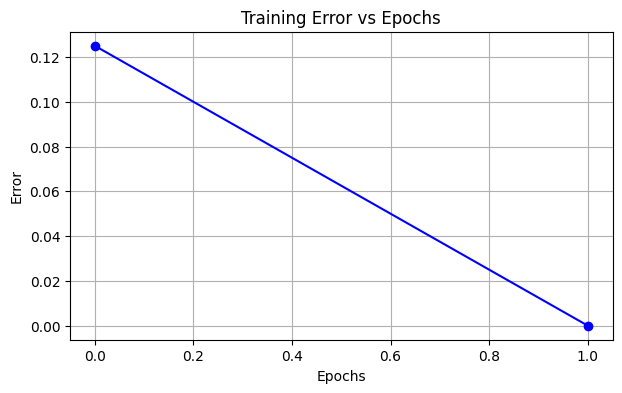

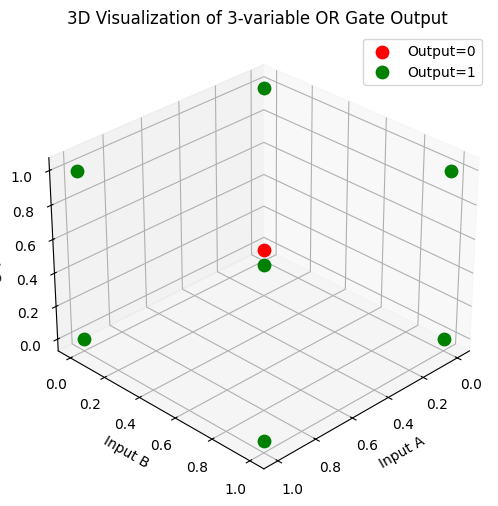

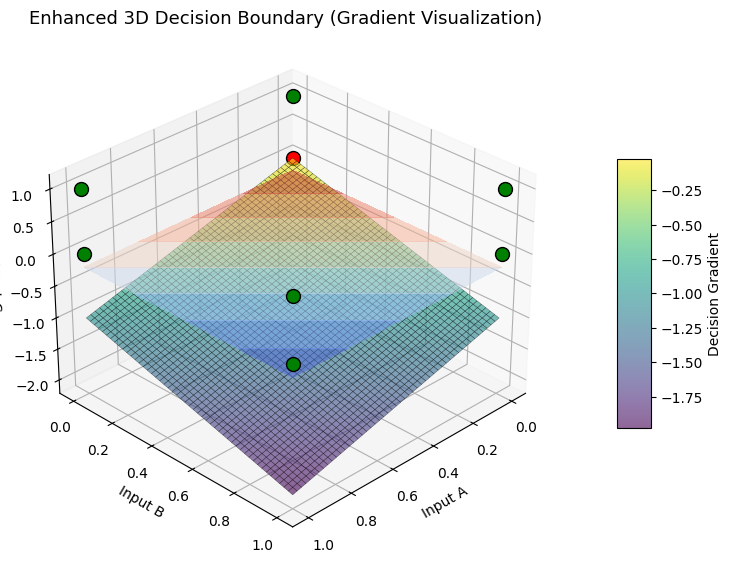

In [1]:
# or_gate_slp_3var.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# 1. Define the dataset (3-variable OR gate)
# ----------------------------
# Inputs (A, B, C)
X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

# Output (A OR B OR C)
y = np.array([0, 1, 1, 1, 1, 1, 1, 1])

# ----------------------------
# 2. Create and train the SLP model
# ----------------------------
model = Perceptron(max_iter=100, eta0=0.1, random_state=42)
errors = []

# Manual training loop to capture error for each epoch
for _ in range(100):
    model.partial_fit(X, y, classes=np.unique(y))
    y_pred = model.predict(X)
    err = np.mean(y_pred != y)
    errors.append(err)
    if err == 0:
        break

# ----------------------------
# 3. Predictions and metrics
# ----------------------------
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred)

# ----------------------------
# 4. Display results
# ----------------------------
print("\n=== 3-Variable OR Gate using Single Layer Perceptron ===")
print("Weights:", model.coef_)
print("Bias:", model.intercept_)
print("\nPredictions:", y_pred)
print("\nAccuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# ----------------------------
# 5. Plot line chart (Error vs Epochs)
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(errors, marker='o', color='blue')
plt.title("Training Error vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ----------------------------
# 6. 3D Visualization of Predictions (like MLP output)
# ----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot colored by predicted output
for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=80, label=f'Output={yi}')

ax.set_title("3D Visualization of 3-variable OR Gate Output")
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Input C")
ax.view_init(30, 45)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# ----------------------------
# 7. Enhanced 3D Visualization with Gradient Decision Boundary
# ----------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter points: green = 1, red = 0
for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k', depthshade=True)

# Create high-resolution mesh grid for smoother plane
x_range = np.linspace(0, 1, 50)
y_range = np.linspace(0, 1, 50)
xx, yy = np.meshgrid(x_range, y_range)

# Extract weights and bias
w = model.coef_[0]
b = model.intercept_[0]

# Compute Z values from the perceptron equation
if w[2] != 0:
    zz = -(w[0] * xx + w[1] * yy + b) / w[2]

    # Add gradient shading to the plane
    surf = ax.plot_surface(xx, yy, zz, cmap='viridis', alpha=0.6, edgecolor='k', linewidth=0.3)

    # Add contour projection on the bottom plane for clarity
    ax.contourf(xx, yy, zz, zdir='z', offset=-0.2, cmap='coolwarm', alpha=0.5)
    fig.colorbar(surf, shrink=0.5, aspect=8, pad=0.1, label='Decision Gradient')
else:
    print("Cannot plot plane: w3 = 0")

ax.set_title("Enhanced 3D Decision Boundary (Gradient Visualization)", fontsize=13)
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Input C")
ax.view_init(30, 45)

plt.show()

In [2]:
import joblib
joblib.dump(model, "or_gate_slp.pkl")

['or_gate_slp.pkl']